In [43]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as p
import numpy as np
import flamingo_analysis as fa 
import tangos as db

def test_stellar_mass_sfr_relation(tsnum=8):
    p.figure(figsize=(18,5))
    db.init_db('data-720.db')
    sfr, mstar, m200m = db.get_timestep(f"L0200N0720_HYDRO_FIDUCIAL/%{tsnum}.hdf5").calculate_all("InclusiveSphere_30kpc_StarFormationRate*0.0102", "InclusiveSphere_30kpc_StellarMass*1e10", "M200m()")
    s_sfr = sfr/mstar
    p.subplot(131)
    mask = m200m>2e12 
    s_sfr[s_sfr<1e-13] = 1e-13
    sfr[sfr<0.01] = 0.01
    p.plot(np.log10(m200m[mask]), np.log10(mstar[mask]), 'r.')
    p.subplot(132)
    p.plot(np.log10(mstar[mask]), np.log10(sfr[mask]), 'r.')
    p.subplot(133)
    p.plot(np.log10(mstar[mask]), np.log10(s_sfr[mask]), 'r.')

    db.init_db('data.db')
    sfr, mstar, m200m = db.get_timestep(f"L0200N0360_HYDRO_STRONGEST_AGN/%{tsnum}.hdf5").calculate_all("InclusiveSphere_30kpc_StarFormationRate*0.0102", "InclusiveSphere_30kpc_StellarMass*1e10", "M200m()")
    s_sfr = sfr/mstar
    s_sfr[s_sfr<1e-13] = 1e-13
    sfr[sfr<0.01] = 0.01
    mask = m200m>2e12 
    p.subplot(131)
    p.plot(np.log10(m200m[mask]), np.log10(mstar[mask]), 'g.')
    p.subplot(132)
    p.plot(np.log10(mstar[mask]), np.log10(sfr[mask]), 'g.')
    p.subplot(133)
    p.plot(np.log10(mstar[mask]), np.log10(s_sfr[mask]), 'g.')

    redshift = db.get_timestep(f'L0200N0360_HYDRO_FIDUCIAL/%{tsnum}.hdf5').redshift

    p.subplot(131)
    p.legend(['high-res', 'low-res'])
    p.xlabel(r"$\log_{10}(M_{200m}/M_\odot)$")
    p.ylabel(r"$\log_{10}(M_\star/M_\odot)$")
    p.title(f"z={redshift:.1f}")

    p.subplot(132)
    p.xlabel(r"$\log_{10}(M_\star/M_\odot)$")
    p.ylabel(r"$\log_{10}(\mathrm{SFR}/M_\odot\,\mathrm{yr}^{-1})$")
    p.title(f"z={redshift:.1f}")

    p.subplot(133)
    p.xlabel(r"$\log_{10}(M_\star/M_\odot)$")
    p.ylabel(r"$\log_{10}(\mathrm{sSFR}/\mathrm{yr}^{-1})$")
    p.gca().yaxis.tick_right()
    p.gca().yaxis.set_label_position("right")
    p.title(f"z={redshift:.1f}")
    p.tight_layout()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


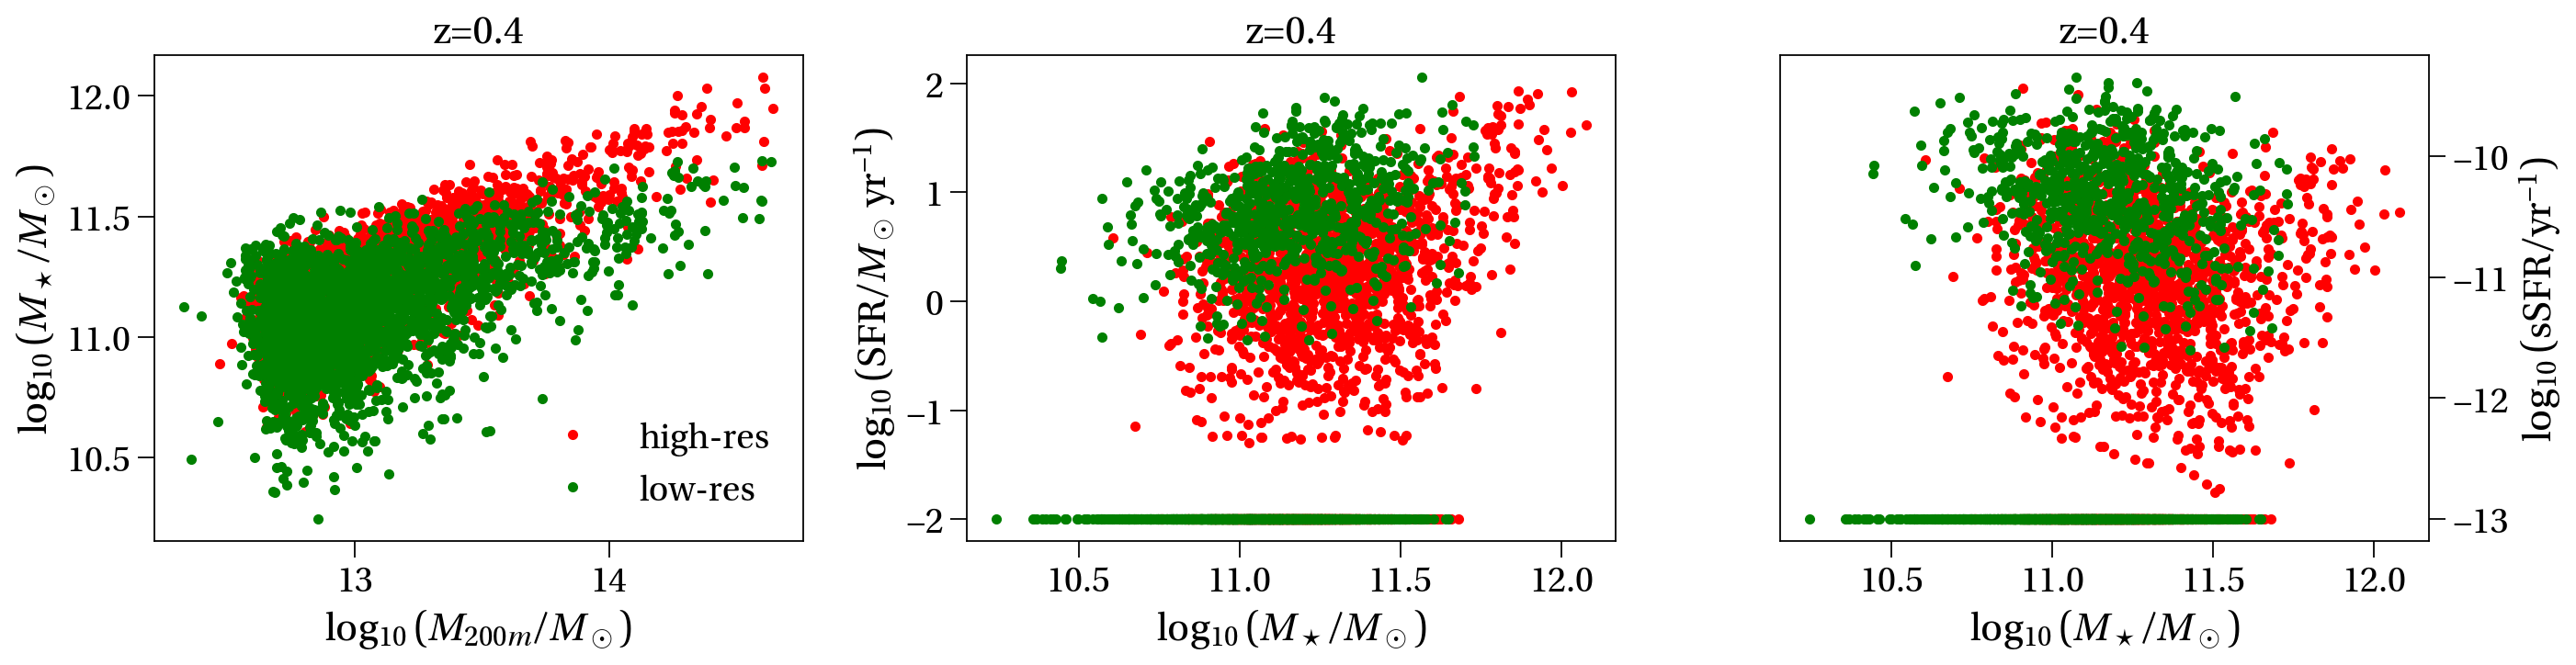

In [44]:
test_stellar_mass_sfr_relation(4)

In [52]:
def test_gas_mass_profiles(M_name='M200m()', M_range=(12.5, 13.5), tsnum=4):
    fa.ranges=[M_range]
    fa.mass_name=M_name

    p.figure(figsize=(12, 5))
    match M_name:
        case 'InclusiveSphere_30kpc_StellarMass*1e10':
            M_name_latex = r"M_{\mathrm{stellar}}"
        case 'M200m()':
            M_name_latex = r"M_{200m}"

    db.init_db('data.db')
    fa.make_profile_plots_with_cut('mass_enclosed', 'InclusiveSphere_30kpc_StarFormationRate*0.0102/(1e10 * InclusiveSphere_30kpc_StellarMass)', cut_value=0.5e-11,
                                tsnum=tsnum, box="L0200N0360_HYDRO_FIDUCIAL", plot_kwargs={'color':'g', 'label' : 'low-res'})
    redshift = db.get_timestep(f'L0200N0360_HYDRO_FIDUCIAL/%{tsnum}.hdf5').redshift

    db.init_db('data-720.db')
    fa.make_profile_plots_with_cut('mass_enclosed', 'InclusiveSphere_30kpc_StarFormationRate*0.0102/(1e10 * InclusiveSphere_30kpc_StellarMass)', 
                                   cut_value=1.0e-11,
                                tsnum=tsnum, box="L0200N0720_HYDRO_FIDUCIAL", plot_kwargs={'color':'r', 'label' : 'high-res'}, newfig=False)

    
    p.subplot(121)
    p.title(rf"$z={redshift:.1f}$, $10^{{{M_range[0]}}} < {M_name_latex}/M_\odot < 10^{{{M_range[1]}}}$")
    p.subplot(122)
    fa.remove_existing_legend()
    p.title(rf"$z={redshift:.1f}$, $10^{{{M_range[0]}}} < {M_name_latex}/M_\odot < 10^{{{M_range[1]}}}$")

Plotting mass_enclosed profiles for L0200N0360_HYDRO_FIDUCIAL/%4.hdf5
Plotting mass_enclosed profiles for L0200N0360_HYDRO_FIDUCIAL/%4.hdf5
Plotting mass_enclosed profiles for L0200N0720_HYDRO_FIDUCIAL/%4.hdf5
Plotting mass_enclosed profiles for L0200N0720_HYDRO_FIDUCIAL/%4.hdf5


<Figure size 960x400 with 0 Axes>

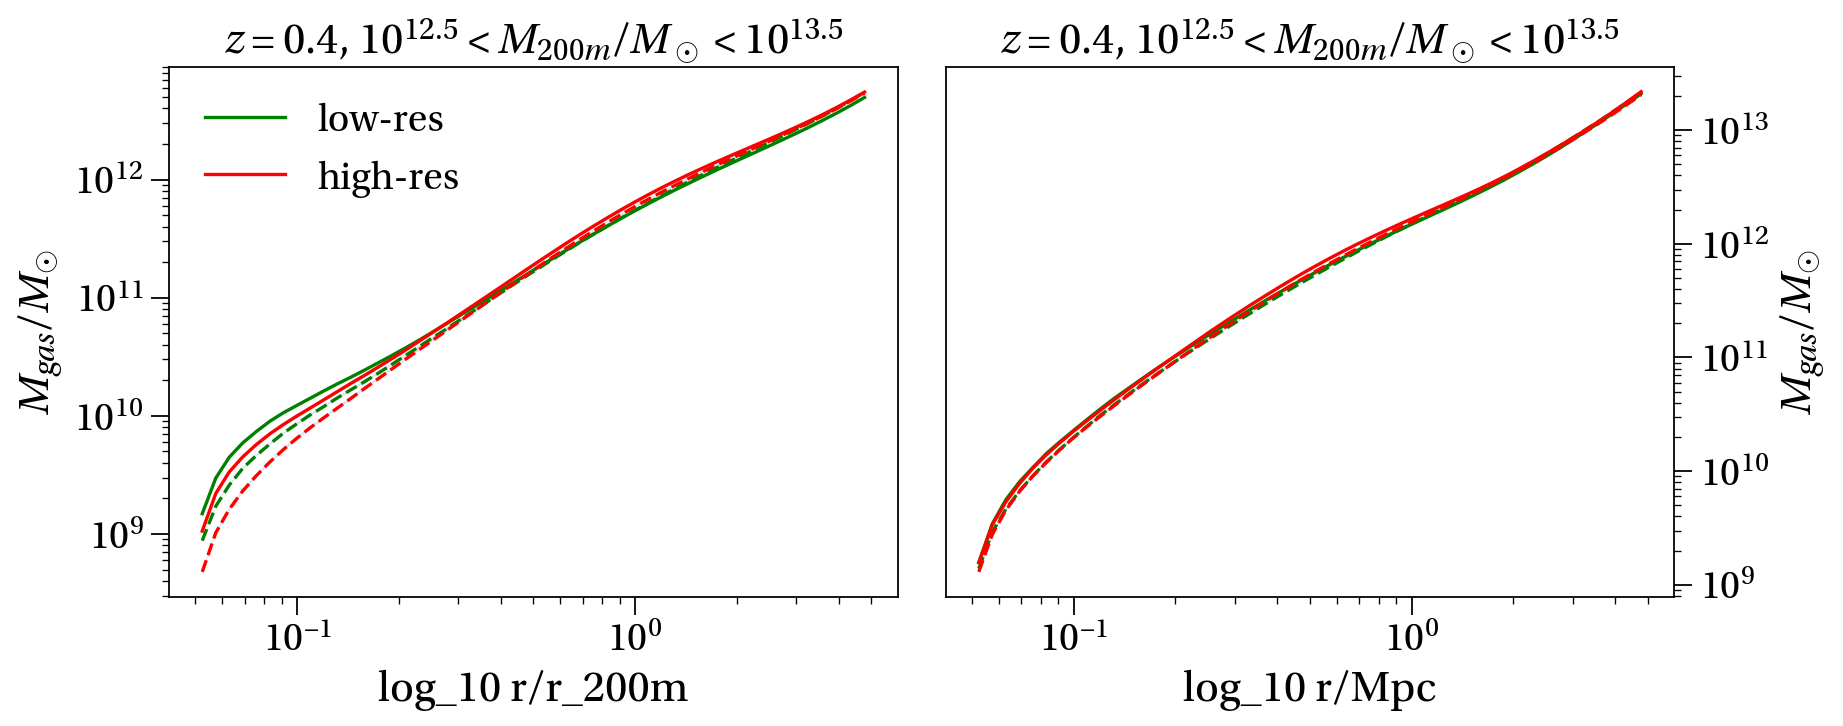

In [53]:
test_gas_mass_profiles()

Plotting mass_enclosed profiles for L0200N0360_HYDRO_FIDUCIAL/%4.hdf5
Plotting mass_enclosed profiles for L0200N0360_HYDRO_FIDUCIAL/%4.hdf5
Plotting mass_enclosed profiles for L0200N0720_HYDRO_FIDUCIAL/%4.hdf5
Plotting mass_enclosed profiles for L0200N0720_HYDRO_FIDUCIAL/%4.hdf5


(500000000.0, 10000000000000.0)

<Figure size 960x400 with 0 Axes>

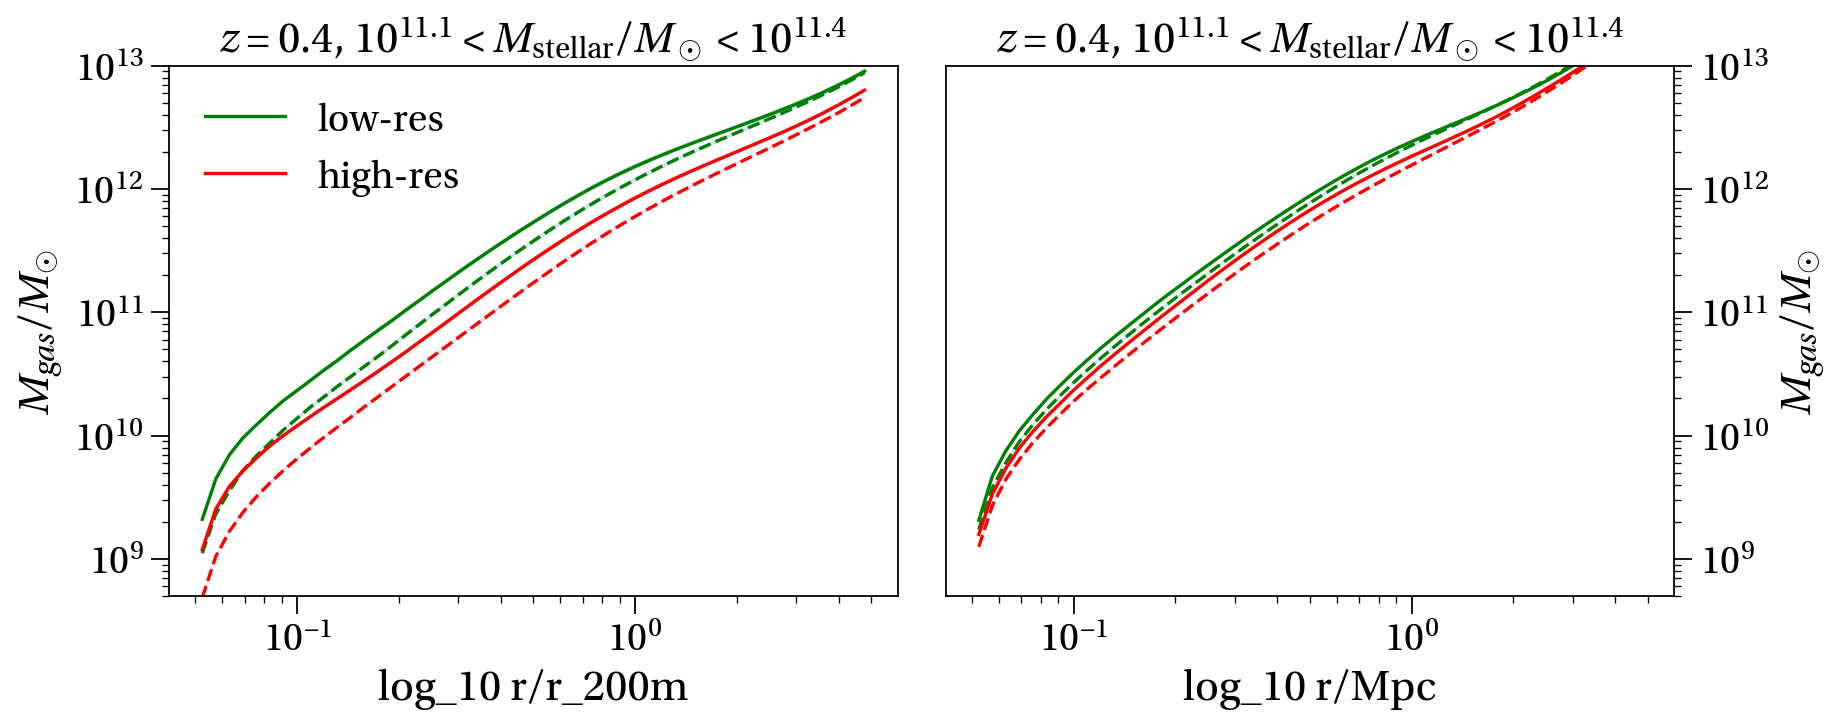

In [54]:
test_gas_mass_profiles('InclusiveSphere_30kpc_StellarMass*1e10', (11.1, 11.4), tsnum=4)
p.subplot(121)
p.ylim(5e8, 1e13)
p.subplot(122)
p.ylim(5e8, 1e13)

In [40]:
m200m, r200m, mstar = db.get_timestep("%720%/%4.hdf5").calculate_all("M200m()", "r200m", "InclusiveSphere_30kpc_StellarMass*1e10")

(array([ 2.,  2.,  6.,  3.,  8.,  9., 13., 30., 25., 34., 34., 36., 39.,
        31., 33., 44., 42., 37., 43., 26., 30., 31., 38., 35., 28., 39.,
        37., 41., 17., 31., 33., 44., 33., 24., 26., 21., 22., 20., 21.,
        19., 18., 16., 18., 18., 13., 13.,  9., 13., 11.,  9.,  9.,  9.,
         8.,  9.,  7., 10.,  8.,  5.,  3.,  3.,  7.,  5.,  3.,  4.,  3.,
         1.,  2.,  3.,  1.,  0.,  1.,  1.,  2.,  1.,  0.,  0.,  2.,  0.,
         2.,  1.,  1.,  1.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  1.]),
 array([12.55059564, 12.56624195, 12.58188826, 12.59753457, 12.61318088,
        12.62882719, 12.64447351, 12.66011982, 12.67576613, 12.69141244,
        12.70705875, 12.72270506, 12.73835137, 12.75399768, 12.76964399,
        12.78529031, 12.80093662, 12.81658293, 12.83222924, 12.84787555,
        12.86352186, 12.87916817, 12.89481448, 12.9104608 , 12.92610711,
        12.94175342, 12.95739973, 12.97304604, 12.98869235, 13.004338

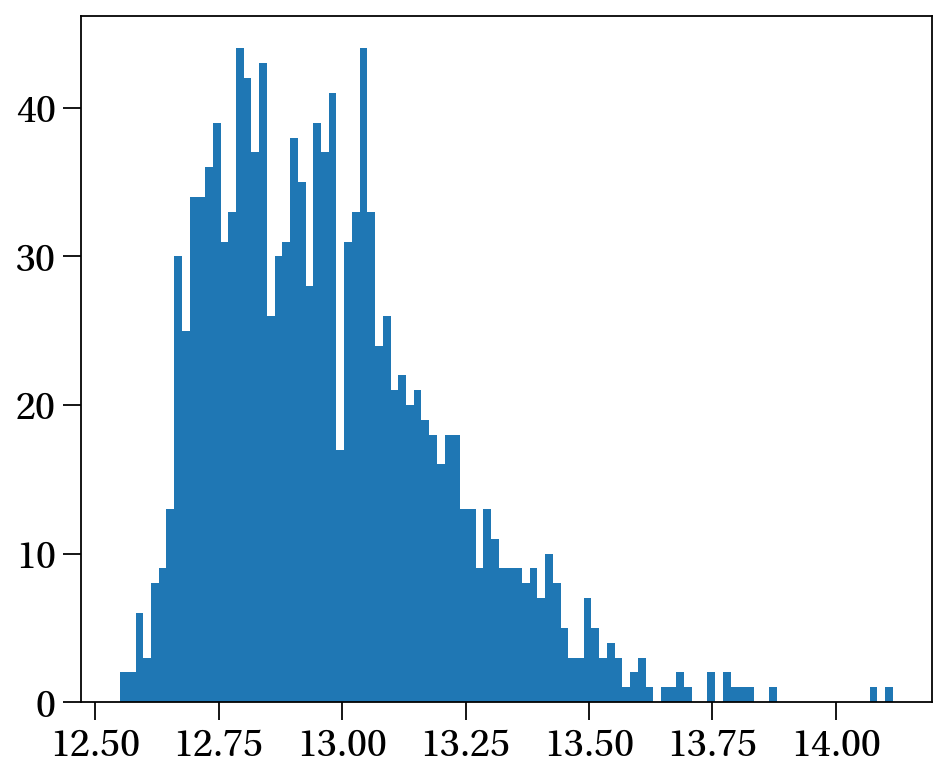

In [39]:
mask = (mstar>10**11.1) &  (mstar<10**11.4)
p.hist(np.log10(m200m[mask]), bins=100)

(array([ 4.,  8., 13., 29., 50., 58., 62., 52., 65., 67., 61., 37., 52.,
        54., 44., 45., 65., 28., 45., 51., 46., 35., 26., 27., 29., 24.,
        22., 18., 21., 20., 13., 14., 13., 13.,  8.,  9., 11.,  8., 13.,
         4., 11.,  7.,  7.,  3.,  2.,  7.,  4.,  4.,  3.,  4.,  3.,  0.,
         2.,  3.,  0.,  1.,  1.,  0.,  1.,  2.,  0.,  1.,  0.,  0.,  2.,
         0.,  0.,  2.,  0.,  2.,  1.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  1.]),
 array([ 339.82245942,  347.71688264,  355.61130586,  363.50572908,
         371.4001523 ,  379.29457552,  387.18899875,  395.08342197,
         402.97784519,  410.87226841,  418.76669163,  426.66111485,
         434.55553808,  442.4499613 ,  450.34438452,  458.23880774,
         466.13323096,  474.02765418,  481.9220774 ,  489.81650063,
         497.71092385,  505.60534707,  513.49977029,  521.39419351,
         529.28861673,  53

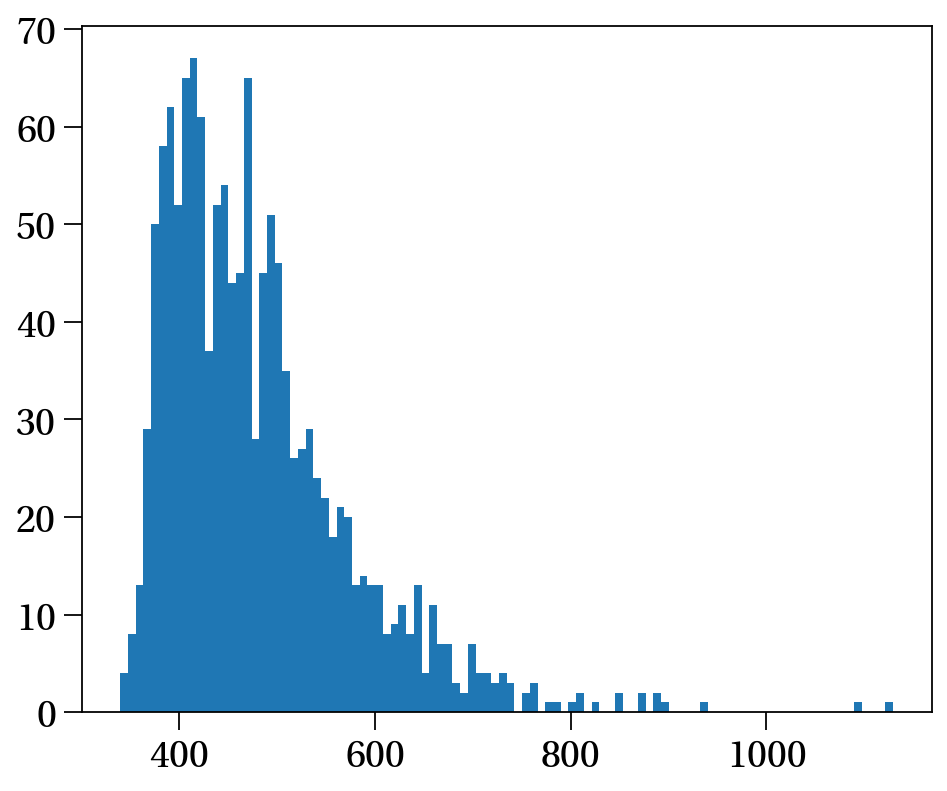

In [41]:
p.hist(r200m[mask], bins=100)